**G1-3:** <br>
Daniel Cruz Flores (1709912) <br>
Marco Mejías Alés (1710748) <br>
Marc Solés i Rojas (1710741) <br>
Samuel Jesús Outeda Aponte (1711378)

In [47]:
import os
import cv2
import numpy as np
import metrikz
import matplotlib.pyplot as plt
from PIL import Image

In [48]:
#Exercici 1: Anàlisis Raw sense comprimir

def calculPesMB(megapixels, bits_pixel_total): #Directament en MB per evitar numeros gegants
   return (megapixels * bits_pixel_total) / 8

print(f'Pes de la imatge en disc sense compresio: {calculPesMB(61,16)} MB')

Pes de la imatge en disc sense compresio: 122.0 MB


In [49]:
##Exercici 2: Analisis JPEG
DATASET_DIR = "./"
OUTPUT_DIR = "output"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

#inicialitzar
images = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith('.png')]
qualities = [1] + list(range(10, 101, 10))

mse_results = {img: [] for img in images}
ratio_results = {img: [] for img in images}

In [50]:
print("--- Análisis JPEG (OpenCV + metrikz) ---")
for img_name in images:
    orig_path = os.path.join(DATASET_DIR, img_name)
    source = cv2.imread(orig_path, cv2.IMREAD_COLOR)# Llegir PNG

    if source is None:
        print(f"Error: No se pudo cargar {img_name}")
        continue
        
    orig_size = os.path.getsize(orig_path)
    source_np = np.asarray(source)
    
    for q in qualities:
        base_name = os.path.splitext(img_name)[0]
        jpeg_path = os.path.join(OUTPUT_DIR, f"{base_name}_q{q}.jpg")
        
        # Tasca 2a: Comprimir i guardar
        cv2.imwrite(jpeg_path, source, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        
        # Llegir imatge resultant
        target = cv2.imread(jpeg_path, cv2.IMREAD_COLOR)
        target_np = np.asarray(target)
        
        # Calcular MSE utilizant la libreria metrikz
        mse = metrikz.mse(source_np, target_np)
        mse_results[img_name].append(mse)
        
        # # Tasca 2b: Calcular Ratio de compresión: original / resultante
        jpeg_size = os.path.getsize(jpeg_path)
        ratio = orig_size / jpeg_size
        ratio_results[img_name].append(ratio)

print("Proces finalitzat!!")


--- Análisis JPEG (OpenCV + metrikz) ---
Proces finalitzat!!


Gráfica 1 guardada.



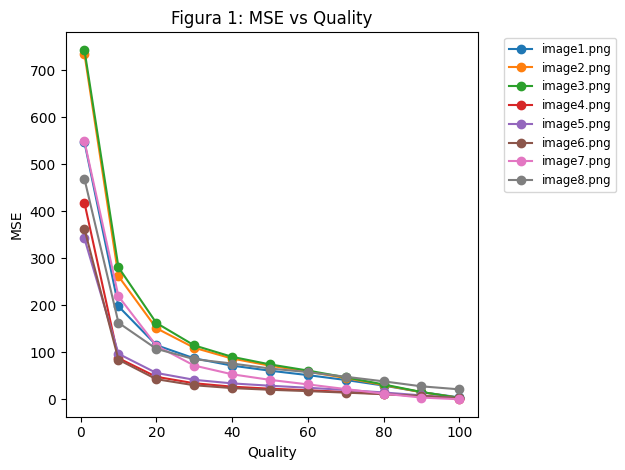

In [51]:
# Generar Figura 1: MSE vs Quality
plt.figure(1)
for img_name in images:
    plt.plot(qualities, mse_results[img_name], marker='o', label=img_name)
plt.xlabel('Quality')
plt.ylabel('MSE')
plt.title('Figura 1: MSE vs Quality')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figura_1_MSE.png"))
print("Gráfica 1 guardada.\n")

Gráfica 2 guardada.



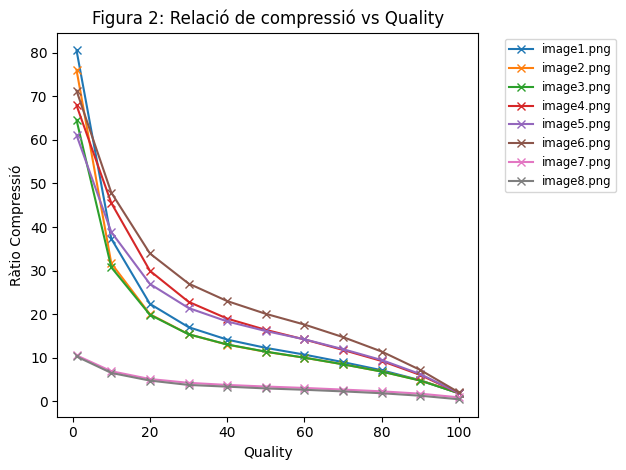

In [52]:
# Generar Figura 2: Ratio compresión vs Quality
plt.figure(2)
for img_name in images:
    plt.plot(qualities, ratio_results[img_name], marker='x', label=img_name)
plt.xlabel('Quality')
plt.ylabel('Ràtio Compressió')
plt.title('Figura 2: Relació de compressió vs Quality')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figura_2_Ratio.png"))
print("Gráfica 2 guardada.\n")


In [53]:
print("--- Análisis GIF (PIL) ---")

for img_name in images:
    orig_path = os.path.join(DATASET_DIR, img_name)
    base_name = os.path.splitext(img_name)[0]
    img_orig = Image.open(orig_path)

    print(f"ANÀLISI: {img_name}")

    #PNG ORIGINAL 
    colors_png = img_orig.getcolors(maxcolors=16777216)
    if colors_png:
        print(f"[PNG] Total colors diferents: {len(colors_png)}")
        # Ordenem per freqüència (els més comuns)
        sorted_png = sorted(colors_png, key=lambda x: x[0], reverse=True)
        print(f"[PNG] Top 3 colors (Frequència, RGB): {sorted_png[:3]}")

    #CONVERSIÓ A GIF 
    gif_path = os.path.join(OUTPUT_DIR, f"{base_name}.gif")
    img_gif = img_orig.convert("P", palette=Image.ADAPTIVE)
    img_gif.save(gif_path, "GIF")
    
    colors_gif = img_gif.getcolors(maxcolors=256)
    if colors_gif:
        print(f"[GIF] Total colors diferents: {len(colors_gif)}")
        sorted_gif = sorted(colors_gif, key=lambda x: x[0], reverse=True)
        # Obtenim la paleta real (RGB)
        palette = img_gif.getpalette() # Llista plana [R,G,B, R,G,B...]
        
        print("[GIF] Top 3 colors freqüents (Frequència, Índex Paleta):")
        for count, index in sorted_gif[:3]:
            r = palette[index*3]
            g = palette[index*3 + 1]
            b = palette[index*3 + 2]
            print(f"   Índex {index}: ({r}, {g}, {b}) - {count} vegades")
        print('\n')

    # MODIFICACIÓ COMPONENT R=0 ---
    # Fem servir 'in' per si el fitxer es diu "image3" o "3"
    if any(n in base_name for n in ["3", "7", "8"]):
        print(f"--> Aplicant R=0 a la paleta de: {base_name}") # Debug per confirmar que entra
        
        palette_mod = list(img_gif.getpalette()) 
        
        # La paleta GIF és una llista plana: [R0, G0, B0, R1, G1, B1, ...] 
        # Modifiquem només la component R (índexs 0, 3, 6...) a 0 
        for i in range(0, len(palette_mod), 3):
            palette_mod[i] = 0

        img_gif.putpalette(palette_mod)
        mod_gif_path = os.path.join(OUTPUT_DIR, f"{base_name}_R0.gif")
        img_gif.save(mod_gif_path, "GIF")
        print(f"Paleta modificada guardada com: {base_name}_R0.gif\n")

--- Análisis GIF (PIL) ---
ANÀLISI: image1.png
[PNG] Total colors diferents: 55117
[PNG] Top 3 colors (Frequència, RGB): [(3467, (99, 99, 99)), (768, (0, 0, 0)), (719, (28, 27, 24))]
[GIF] Total colors diferents: 256
[GIF] Top 3 colors freqüents (Frequència, Índex Paleta):
   Índex 110: (99, 99, 99) - 4093 vegades
   Índex 5: (224, 188, 41) - 3649 vegades
   Índex 215: (48, 43, 33) - 3348 vegades


ANÀLISI: image2.png
[PNG] Total colors diferents: 63558
[PNG] Top 3 colors (Frequència, RGB): [(2968, (99, 99, 99)), (874, (34, 24, 22)), (851, (35, 25, 24))]
[GIF] Total colors diferents: 256
[GIF] Top 3 colors freqüents (Frequència, Índex Paleta):
   Índex 228: (34, 24, 23) - 3625 vegades
   Índex 46: (127, 107, 88) - 3485 vegades
   Índex 82: (99, 99, 99) - 3255 vegades


ANÀLISI: image3.png
[PNG] Total colors diferents: 45558
[PNG] Top 3 colors (Frequència, RGB): [(6792, (255, 255, 255)), (3243, (99, 99, 99)), (887, (52, 52, 52))]
[GIF] Total colors diferents: 256
[GIF] Top 3 colors freq